# Model Management with MLflow

As you develop machine learning models, you will find that you need to manage many different versions of your models. You may want to compare models, roll back to previous versions, or deploy multiple versions of a model to A/B test which one is better. [MLflow](https://MLflow.org) is one of many tools and frameworks that helps you manage this process. There are lots of alternatives in this space, including [Kubeflow](https://www.kubeflow.org), [DVC](https://dvc.org), and [Metaflow](https://metaflow.org).

We are looking at MLflow specifically because it is a lightweight, open-source platform that integrates with many popular machine learning libraries, including TensorFlow, PyTorch, and scikit-learn. It also has a simple API that makes it easy to log metrics, parameters, and artifacts (like models) from your machine learning code - helping you start tracking your experiments quickly with as little fuss as possible.

We will not cover all of MLflow's features here, only the basic features that you need to get started. If you want to learn more about MLflow, you can check out the [official documentation](https://www.MLflow.org/docs/latest/index.html).

## Installation

Just install the `mlflow` package either with `pip` or `conda`, and you are good to go. It comes with a built-in tracking server that you can run locally, or you can use a cloud-based tracking server, including ones provided as part of Azure ML and AWS SageMaker.

Unless otherwise specified, `MLflow` will log your experiments to a local directory called `mlruns`. To start the tracking server, run the following command:

```bash
mlflow server
```

A server will start on [`http://127.0.0.1:5000`](http://127.0.0.1:5000). You can access the UI by navigating to that URL in your browser.

## Logging experiments

Anyone who regularly works with machine learning models understands the importance of experiment tracking. Keeping a detailed log of parameters, metrics, and artifacts (such as trained models) for each experiment is crucial for ensuring reproducibility, performance monitoring, and informed decision-making. Without proper logging, comparing models, identifying improvements, and debugging issues become significantly more challenging.

MLflow simplifies this process with a user-friendly API that allows you to systematically track every aspect of your machine learning experiments. By logging parameters, such as learning rates and model architectures, along with evaluation metrics and model artifacts, MLflow helps create a structured and searchable record of your work. This ensures that you can not only reproduce past results but also analyze trends over time, making it easier to identify what works best.

Beyond individual experimentation, proper logging is essential for collaboration. Whether you’re working alone or in a team, having a well-documented history of model runs makes it easier to share insights, compare different approaches, and troubleshoot unexpected results. Additionally, logging supports model governance and compliance, which are increasingly critical in regulated industries where transparency and accountability are required.

Logging is not just a best practice — it’s a fundamental part of the machine learning workflow. MLflow makes this effortless, ensuring that your experiments are well-documented, reproducible, and easy to analyze as you refine your models over time.

## A simple example

Let's exemplify how to use MLflow with a simple use case. We will produce a 2D dataset, and train a variety of models on it. We will log the models, along with their hyperparameters and performance metrics to MLflow so we can reproduce and compare them later.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple dataset
np.random.seed(42)
X = 3 * np.random.rand(1000, 1)
# Produce a sinusoidal curve with some noise
y = 4 + 3 * X + np.sin(2 * np.pi * X) + 0.4 * np.random.randn(1000, 1)

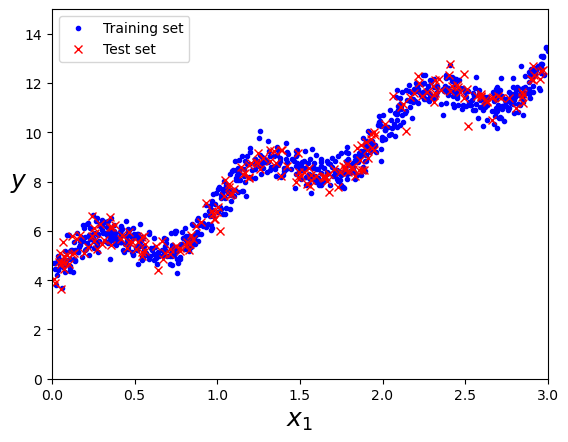

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.DataFrame(np.c_[X, y], columns=["X", "y"])
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

plt.plot(train_set["X"], train_set["y"], "b.")
plt.plot(test_set["X"], test_set["y"], "rx")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 3, 0, 15])
plt.legend(["Training set", "Test set"])
plt.show()

With the necessary dataset out of the way, we can now move on to creating an MLflow *experiment*. An experiment is a set of *runs* that are typically related to a specific goal. For example, you might create an experiment to compare different models on a specific dataset or to optimize a model for a specific metric. Each run within an experiment logs metrics, parameters, and artifacts, which can be compared and analyzed later.

Below, when we run `autolog()`, we are priming MLflow to automatically log all the parameters, metrics, model signatures, models and datasets from our runs. This is a convenient way to ensure that all relevant information is captured without having to manually log each item. This is the easiest way to get started with MLflow, but you can also log items manually if you prefer.

In [3]:
from mlflow import set_experiment
from mlflow.sklearn import autolog

# Name the experiment
set_experiment("sinusoidal_regression")

autolog(
    log_input_examples=True,
    log_model_signatures=True,
    log_models=True,
    log_datasets=True
)

With the initial setup complete, we can now train a simple linear regression model on the dataset. In MLflow you start a run typically with an expression of the form `with MLflow.start_run():`. This creates a new run within the active experiment, which will log all the relevant information for that run. We can then train the model, log the model, and log the performance metrics.

Anything that runs within the `with` block will be logged to MLflow automagically, MLflow supports a wide range of machine learning frameworks - including TensorFlow, PyTorch (via [Lightning](https://lightning.ai/docs/pytorch/stable/)), and scikit-learn.

```{admonition} Tip
:class: tip, dropdown

Always ensure you end your run with `mlflow.end_run()`. This will ensure that all the relevant information is logged to MLflow.
```

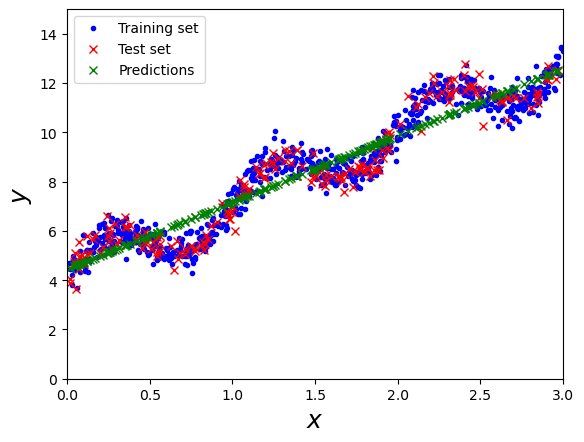

In [4]:
# Create a simple linear regression model
from sklearn.linear_model import LinearRegression
from mlflow import start_run, set_tag, end_run, log_artifact

with start_run(run_name="linear_regression") as run:
    
    set_tag("type", "investigation")
    
    lin_reg = LinearRegression()
    lin_reg.fit(train_set[["X"]], train_set["y"])
    
    # Make a prediction with some random data points
    y_pred = lin_reg.predict(test_set[["X"]])

    # Plot the prediction, include markers for the predicted data points
    plt.plot(train_set["X"], train_set["y"], "b.")
    plt.plot(test_set["X"], test_set["y"], "rx")
    plt.plot(test_set["X"], y_pred, "gx")
    plt.xlabel("$x$", fontsize=18)
    plt.ylabel("$y$", fontsize=18)
    plt.axis([0, 3, 0, 15])
    plt.legend(["Training set", "Test set", "Predictions"])
    
    # Save the plot to a temporary file
    plot_path = "training_test_plot.png"
    plt.savefig(plot_path)
    
    plt.show()
    plt.close()
    
    # Log the plot to mlflow
    log_artifact(plot_path)
    
    end_run()

With the run finished, you can view the results in the MLflow UI. You will see the parameters, metrics, and artifacts logged for the run. You can also compare runs, search for runs, and view the history of runs within the experiment.

![MLflow UI](mlflow-ui.png)

With the data recorded in MLflow, we can use the client API to query the data logged, for example, we can retrieve the logged metrics for the run we just completed.

In [5]:
from mlflow import MlflowClient

# Use the MlflowClient to fetch the run details
client = MlflowClient()
run_data = client.get_run(run.info.run_id).data

# Extract and display the metrics
metrics = run_data.metrics
print("Logged Evaluation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value}")

Logged Evaluation Metrics:
training_mean_absolute_error: 0.6355884400190623
training_mean_squared_error: 0.5864406171896495
training_r2_score: 0.9063114215104214
training_root_mean_squared_error: 0.765794108876302
training_score: 0.9063114215104214


We can continue to log more runs to the same experiment, and compare the results in the MLflow UI. For example, let's create another run, this time with a Random Forest regressor model. Notice that the flow of the code is the same as before, we start a new run, train the model and end the run.

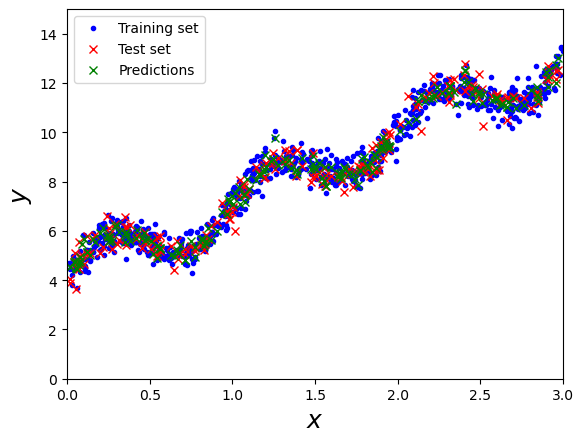

In [6]:
# Predict with a random forest regressor
from sklearn.ensemble import RandomForestRegressor

with start_run(run_name="random_forest") as run:
    
    set_tag("type", "investigation")
    
    forest_reg = RandomForestRegressor()
    forest_reg.fit(train_set[["X"]], train_set["y"])
    
    y_pred = forest_reg.predict(test_set[["X"]])
    
    plt.plot(train_set["X"], train_set["y"], "b.")
    plt.plot(test_set["X"], test_set["y"], "rx")
    plt.plot(test_set["X"], y_pred, "gx")
    plt.xlabel("$x$", fontsize=18)
    plt.ylabel("$y$", fontsize=18)
    plt.axis([0, 3, 0, 15])
    plt.legend(["Training set", "Test set", "Predictions"])
    
    plot_path = "training_test_plot.png"
    plt.savefig(plot_path)
    
    plt.show()
    plt.close()
    
    log_artifact(plot_path)
    
    end_run()

In [7]:
run_data = client.get_run(run.info.run_id).data

metrics = run_data.metrics
print("Logged Evaluation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value}")

Logged Evaluation Metrics:
training_mean_absolute_error: 0.1430542948370046
training_mean_squared_error: 0.032149131110079776
training_r2_score: 0.9948639192015508
training_root_mean_squared_error: 0.17930178780502937
training_score: 0.9948639192015508


## Logging manually

We have so far relied on MLflow's autologging feature to log all the relevant information for our runs. However, you can also log items manually if you prefer. This gives you more control over what is logged, and allows you to log custom metrics, parameters, and artifacts.

Let us add another run to the experiment, this time logging the model manually. We will use a simple neural network model with PyTorch, but this time we will log everything manually.

We start by setting up the network and model.

In [8]:
# Predict with a PyTorch neural network
from torch import nn, device, backends, from_numpy, optim
import torch.nn.functional as F

device = device("mps" if backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
    
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(1, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
# Convert the data to PyTorch tensors
X_train = from_numpy(train_set["X"].values).float().view(-1, 1).to(device)
y_train = from_numpy(train_set["y"].values).float().view(-1, 1).to(device)
X_test = from_numpy(test_set["X"].values).float().view(-1, 1).to(device)
y_test = from_numpy(test_set["y"].values).float().view(-1, 1).to(device)

params = {
        "epochs": 500,
        "learning_rate": 1e-3,
        "batch_size": 8,
        "weight_decay": 1e-4,
}

# Define the neural network, loss function, and optimizer
model = NeuralNetwork().to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])

params.update(
    {
        "loss_function": loss_fn.__class__.__name__,
        "optimizer": optimizer.__class__.__name__,
    }
)

Using device: mps


We then start a new run, just like before, except that now we are logging everything manually - for example, using `mlflow.log_params` to log the hyperparameters, and `mlflow.log_metrics` to log the performance metrics.

Finally, we log the model itself as an artifact. This is a common use case for logging artifacts - you can log any file or directory as an artifact, and it will be stored with the run in MLflow. This is useful for storing models, datasets, and other files that are relevant to the run.

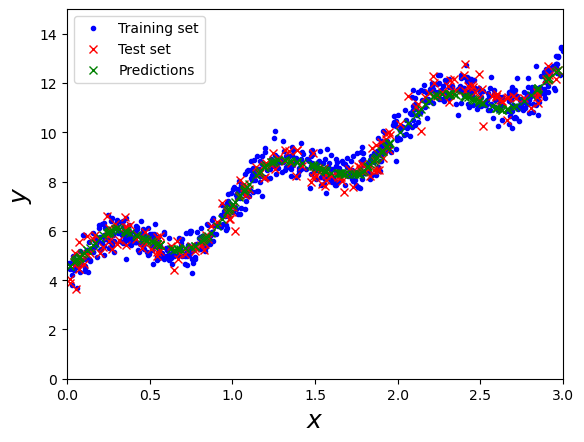

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.data import TensorDataset, DataLoader
from torch import tensor, float32
from mlflow import log_metric, log_params
from mlflow.pytorch import log_model
from mlflow.models import infer_signature

# Create TensorDataset
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)

with start_run(run_name="neural_network") as run:
    
    set_tag("type", "investigation")
    
    # Log the parameters of the model
    log_params(params)
    
    # Train the neural network
    for epoch in range(params["epochs"]):
        
        for batch_X, batch_y in train_loader:
            
            optimizer.zero_grad()
            output = model(batch_X)
            loss = loss_fn(output, batch_y)
            loss.backward()
            optimizer.step()
            
        # Log loss to mlflow
        log_metric("train_loss", loss.item(), step=epoch)
        
    # Make predictions
    y_pred = model(X_test).detach().cpu().numpy()
    y_test_pred = y_test.detach().cpu().numpy()
    
    # Calculate evaluation metrics
    mse = mean_squared_error(y_test_pred, y_pred)
    mae = mean_absolute_error(y_test_pred, y_pred)
    r2 = r2_score(y_test_pred, y_pred)
    
    # Log evaluation metrics to mlflow
    log_metric("test_mse", mse)
    log_metric("test_mae", mae)
    log_metric("test_r2", r2)
    
    # Log the model to mlflow
    
    sample_input = tensor([[0.5]], dtype=float32).to(device)
    sample_output = model(sample_input).detach().cpu().numpy()

    signature = infer_signature(sample_input.cpu().numpy(), sample_output)
    log_model(model, "model", signature=signature, input_example=sample_input.cpu().numpy())
    
    
    plt.plot(train_set["X"], train_set["y"], "b.")
    plt.plot(test_set["X"], test_set["y"], "rx")
    plt.plot(test_set["X"], y_pred, "gx")
    plt.xlabel("$x$", fontsize=18)
    plt.ylabel("$y$", fontsize=18)
    plt.axis([0, 3, 0, 15])
    plt.legend(["Training set", "Test set", "Predictions"])

    plot_path = "training_test_plot.png"
    plt.savefig(plot_path)
    
    plt.show()
    plt.close()

    log_artifact(plot_path)
    
    end_run()

In [10]:
run_data = client.get_run(run.info.run_id).data

metrics = run_data.metrics
print("Logged Evaluation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value}")

Logged Evaluation Metrics:
test_mae: 0.3296917974948883
test_mse: 0.1698240041732788
test_r2: 0.972745418548584
train_loss: 0.08724987506866455


Because our training run logged the training loss as a history, we can not just look at the loss curve in the MLflow UI, but also fetch the loss curve over epochs and plot it ourselves.

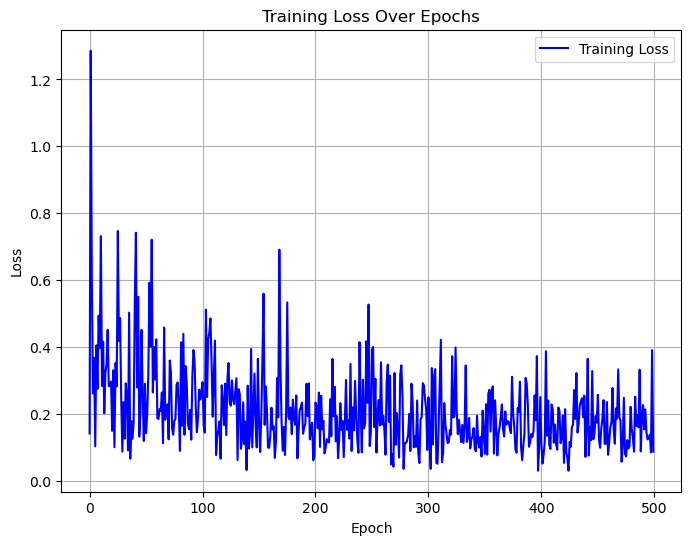

In [11]:
# Retrieve training loss history for the known run_id
train_loss_history = client.get_metric_history(run.info.run_id, "train_loss")

# Convert to a Pandas DataFrame
loss_df = pd.DataFrame([(m.step, m.value) for m in train_loss_history], columns=["epoch", "loss"])

# Plot the training loss
plt.figure(figsize=(8, 6))
plt.plot(loss_df["epoch"], loss_df["loss"], label="Training Loss", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()
plt.grid()
plt.show()

## What else is there ?

We have only scratched the surface of what MLflow can do. In addition to logging experiments, MLflow also supports model deployment, model registry, and model serving. You can use MLflow to deploy models to a variety of platforms, including Azure ML, AWS SageMaker, and Databricks. You can also use the model registry to manage different versions of your models, and serve models using the MLflow model server.

It is a huge tool with a lot of features, but its true power lies in its ability to streamline the entire machine learning lifecycle. MLflow helps teams collaborate efficiently, ensuring that every experiment, model version, and deployment is well-documented and reproducible.

Beyond experiment tracking and deployment, MLflow also supports:

- Automated Model Packaging – You can package models with their dependencies using MLflow’s built-in support for Conda and Docker, making them easy to deploy anywhere.
- Scalability – Whether you are working on a small prototype or deploying models at scale in production, MLflow integrates seamlessly with Kubernetes and cloud services.
- Interoperability – MLflow supports various machine learning frameworks, including TensorFlow, Scikit-Learn, PyTorch, and XGBoost, making it a versatile choice for different workflows.
- Hyperparameter Optimization – Through integrations with tools like [Optuna](https://optuna.org) and [Hyperopt](http://hyperopt.github.io/hyperopt/), MLflow makes tuning machine learning models more systematic and efficient.

Despite its comprehensive feature set, MLflow remains easy to adopt, with a simple API that integrates into existing workflows with minimal effort. Whether you're an individual practitioner or part of a large team, it provides a structured and scalable way to manage machine learning projects from start to finish.